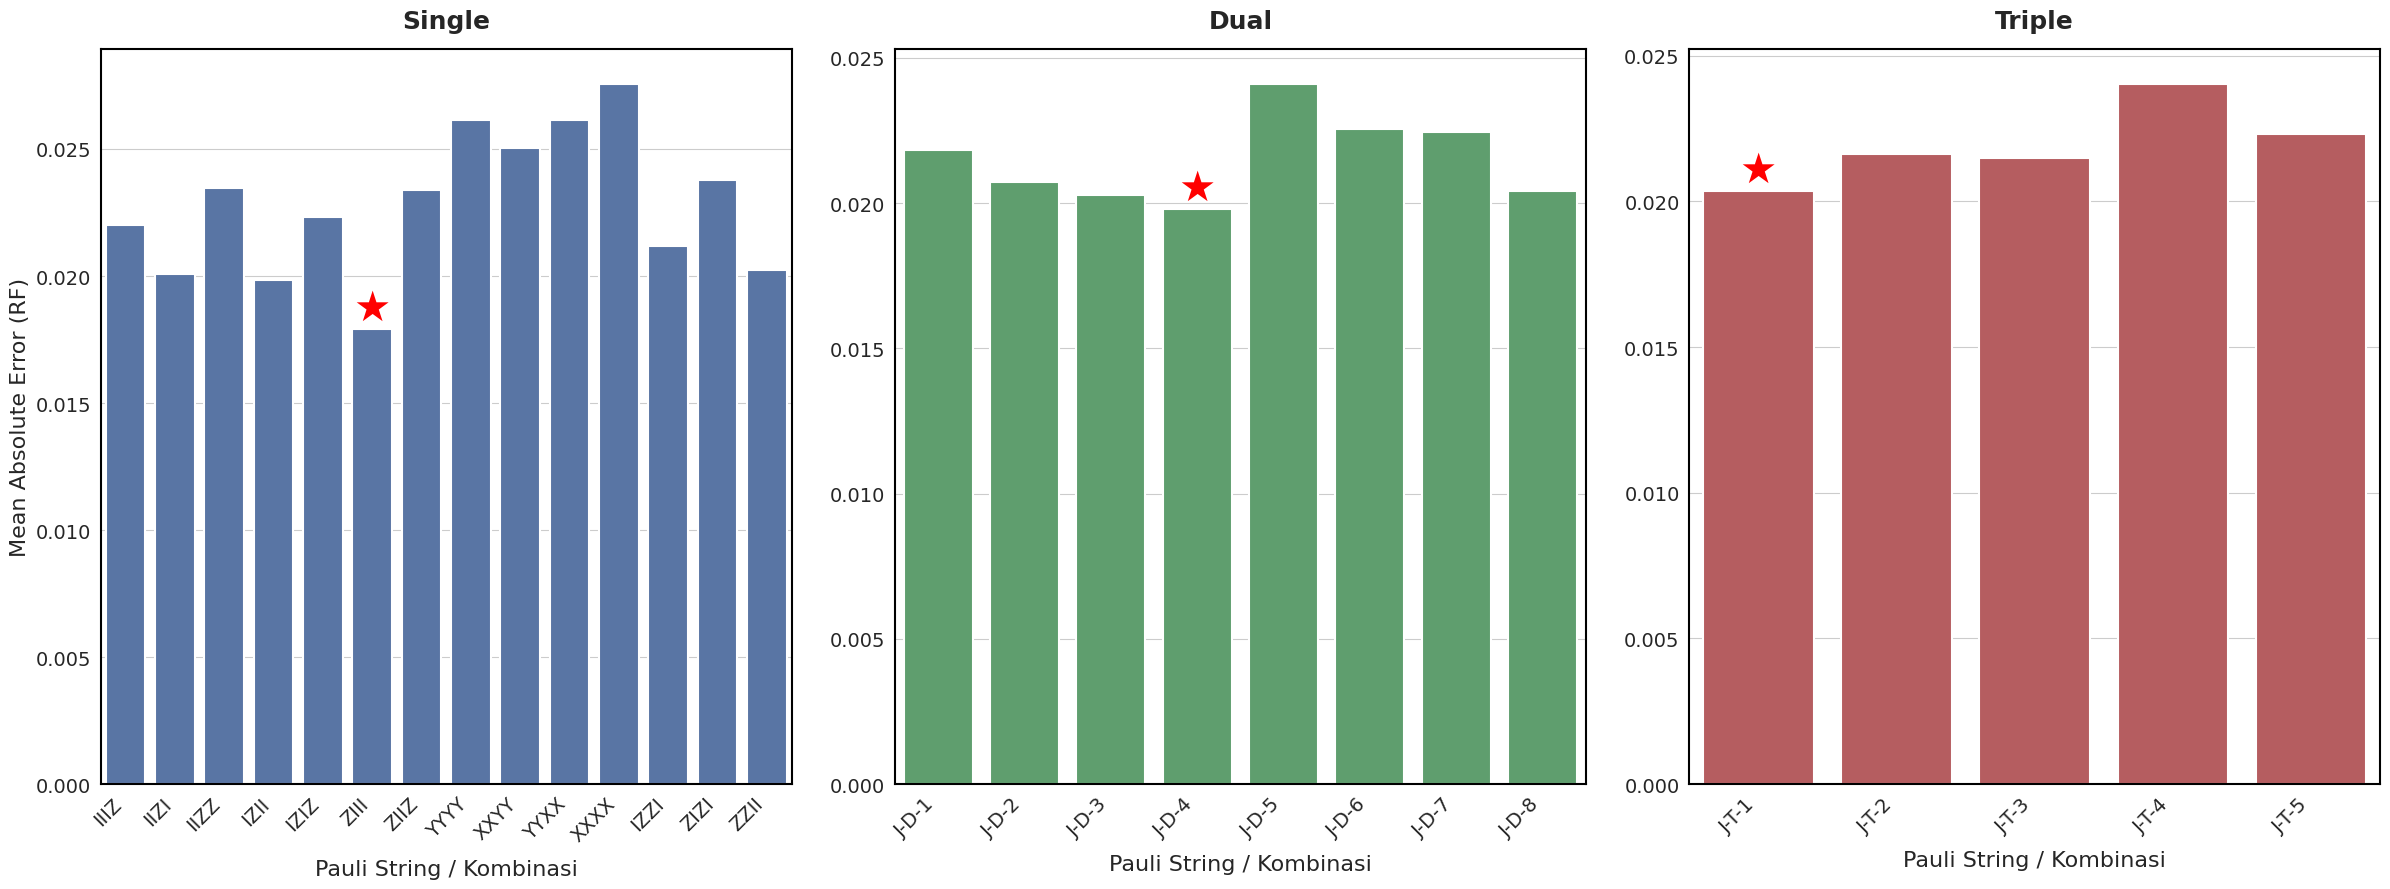

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import numpy as np

# --- 1. CONFIGURATION & MAPPING ---
target_versions = ['V10'] 
target_mapper = 'bk' 
base_root_dir = '../' 
cardinalities = ['single','dual','triple'] 

# MAPPING DICTIONARY (Jordan-Wigner Pauli Strings)
pauli_map_jw = {
    '1': 'IIII',  '2': 'IIIZ',  '3': 'IIZI',  '4': 'IIZZ',
    '5': 'IZII',  '6': 'IZIZ',  '7': 'ZIII',  '8': 'ZIIZ',
    '9': 'YYYY',  '10': 'XXYY', '11': 'YYXX', '12': 'XXXX',
    '13': 'IZZI', '14': 'ZIZI', '15': 'ZZII'
}

pauli_map_bk = {
    '1': 'IIII',  '2': 'IIIZ',  '3': 'IIZZ',  '4': 'IIZI',
    '5': 'IZII',  '6': 'IZIZ',  '7': 'ZZZI',  '8': 'ZZZZ',
    '9': 'ZXIX',  '10': 'IXZX', '11': 'ZXZX', '12': 'IXIX',
    '13': 'IZZZ', '14': 'ZZIZ', '15': 'ZIZI'
}

pauli_map_parity = {
    '1': 'II', '2': 'IZ', '3': 'ZI', '4': 'ZZ', '5': 'XX'
}

def get_pauli_label(dataset_name):
    match = re.search(r'S-(\d+)', dataset_name)
    if match:
        num_id = match.group(1)
        return pauli_map_bk.get(num_id, dataset_name)
    return dataset_name

def natural_key(text):
    return [int(c) if c.isdigit() else c for c in re.split(r'(\d+)', text)]

# --- 2. LOAD DATA ---
def load_multi_experiments(versions, mapper, root_dir, cardinalities):
    all_experiments = []
    
    for ver in versions:
        folder_name = f"hasil_eksperimen{ver}_{mapper}"
        
        for card in cardinalities:
            full_path = os.path.join(root_dir, folder_name, card)
            
            if not os.path.exists(full_path):
                continue
                
            for dataset_folder in sorted(os.listdir(full_path), key=natural_key):
                csv_path = os.path.join(full_path, dataset_folder, 'ml_training', 'predict_data', 'predicted_data_1.csv')
                
                if os.path.exists(csv_path):
                    df = pd.read_csv(csv_path)
                    mae = (df["RF_energy"] - df["ideal_energy"]).abs().mean()
                    
                    all_experiments.append({
                        'cardinality': card.capitalize(),
                        'dataset_folder': dataset_folder,
                        'pauli_label': get_pauli_label(dataset_folder),
                        'mae': mae
                    })
    
    return pd.DataFrame(all_experiments)

df_summary = load_multi_experiments(target_versions, target_mapper, base_root_dir, cardinalities)

if not df_summary.empty:
    df_summary = df_summary[~df_summary['dataset_folder'].isin(['J-S-1','P-S-1','BK-S-1'])]

# --- 3. VISUALIZATION ---
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(24, 9), sharey=False)
sns.set_style("whitegrid")

# Menentukan warna solid untuk masing-masing kardinalitas (Biru, Hijau, Merah)
card_colors = ['#4C72B0', '#55A868', '#C44E52'] 

for i, card in enumerate(['Single', 'Dual', 'Triple']):
    ax = axes[i]
    if df_summary.empty:
        df_subset = pd.DataFrame()
    else:
        df_subset = df_summary[df_summary['cardinality'] == card]
    
    if df_subset.empty:
        ax.set_title(f"Data tidak ditemukan\n({card})", fontsize=16)
        continue

    unique_datasets_subset = sorted(df_subset['dataset_folder'].unique(), key=natural_key)
    unique_paulis_subset = [get_pauli_label(ds) for ds in unique_datasets_subset]

    # Plotting bar chart dengan border pada batang
    sns.barplot(
        data=df_subset,
        x='pauli_label',
        y='mae',
        order=unique_paulis_subset, 
        color=card_colors[i], 
        # edgecolor='black',
        linewidth=1.5,
        ax=ax
    )

    # --- PENAMBAHAN BORDER KOTAK PADA TIAP SUBPLOT ---
    for spine in ax.spines.values():
        spine.set_visible(True)      # Memastikan garis tepi terlihat
        spine.set_color('black')     # Mewarnai garis tepi menjadi hitam
        spine.set_linewidth(1.5)     # Mengatur ketebalan garis kotak grafik

    # --- 4. ANNOTATION ---
    for container in ax.containers:
        values = [bar.get_height() for bar in container]
        valid_values = [v for v in values if not np.isnan(v)]
        if not valid_values: continue
        min_val = min(valid_values)
        
        for bar in container:
            height = bar.get_height()
            if np.isnan(height): continue
            if abs(height - min_val) < 1e-9:
                ax.text(
                    bar.get_x() + bar.get_width()/2, height, 
                    '★', ha='center', va='bottom', color='red', fontsize=30, fontweight='bold'
                )

    # --- 5. FORMATTING PER SUBPLOT ---
    ax.set_title(f"{card}", fontsize=18, fontweight='bold', pad=15)
    
    if i == 0:
        ax.set_ylabel("Mean Absolute Error (RF)", fontsize=16)
    else:
        ax.set_ylabel("") 
        
    ax.set_xlabel("Pauli String / Kombinasi", fontsize=16, labelpad=10)
    
    ax.tick_params(axis='y', labelsize=14)
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=14)

# Legenda dihilangkan sepenuhnya
plt.tight_layout()
plt.subplots_adjust(wspace=0.15) 
plt.show()

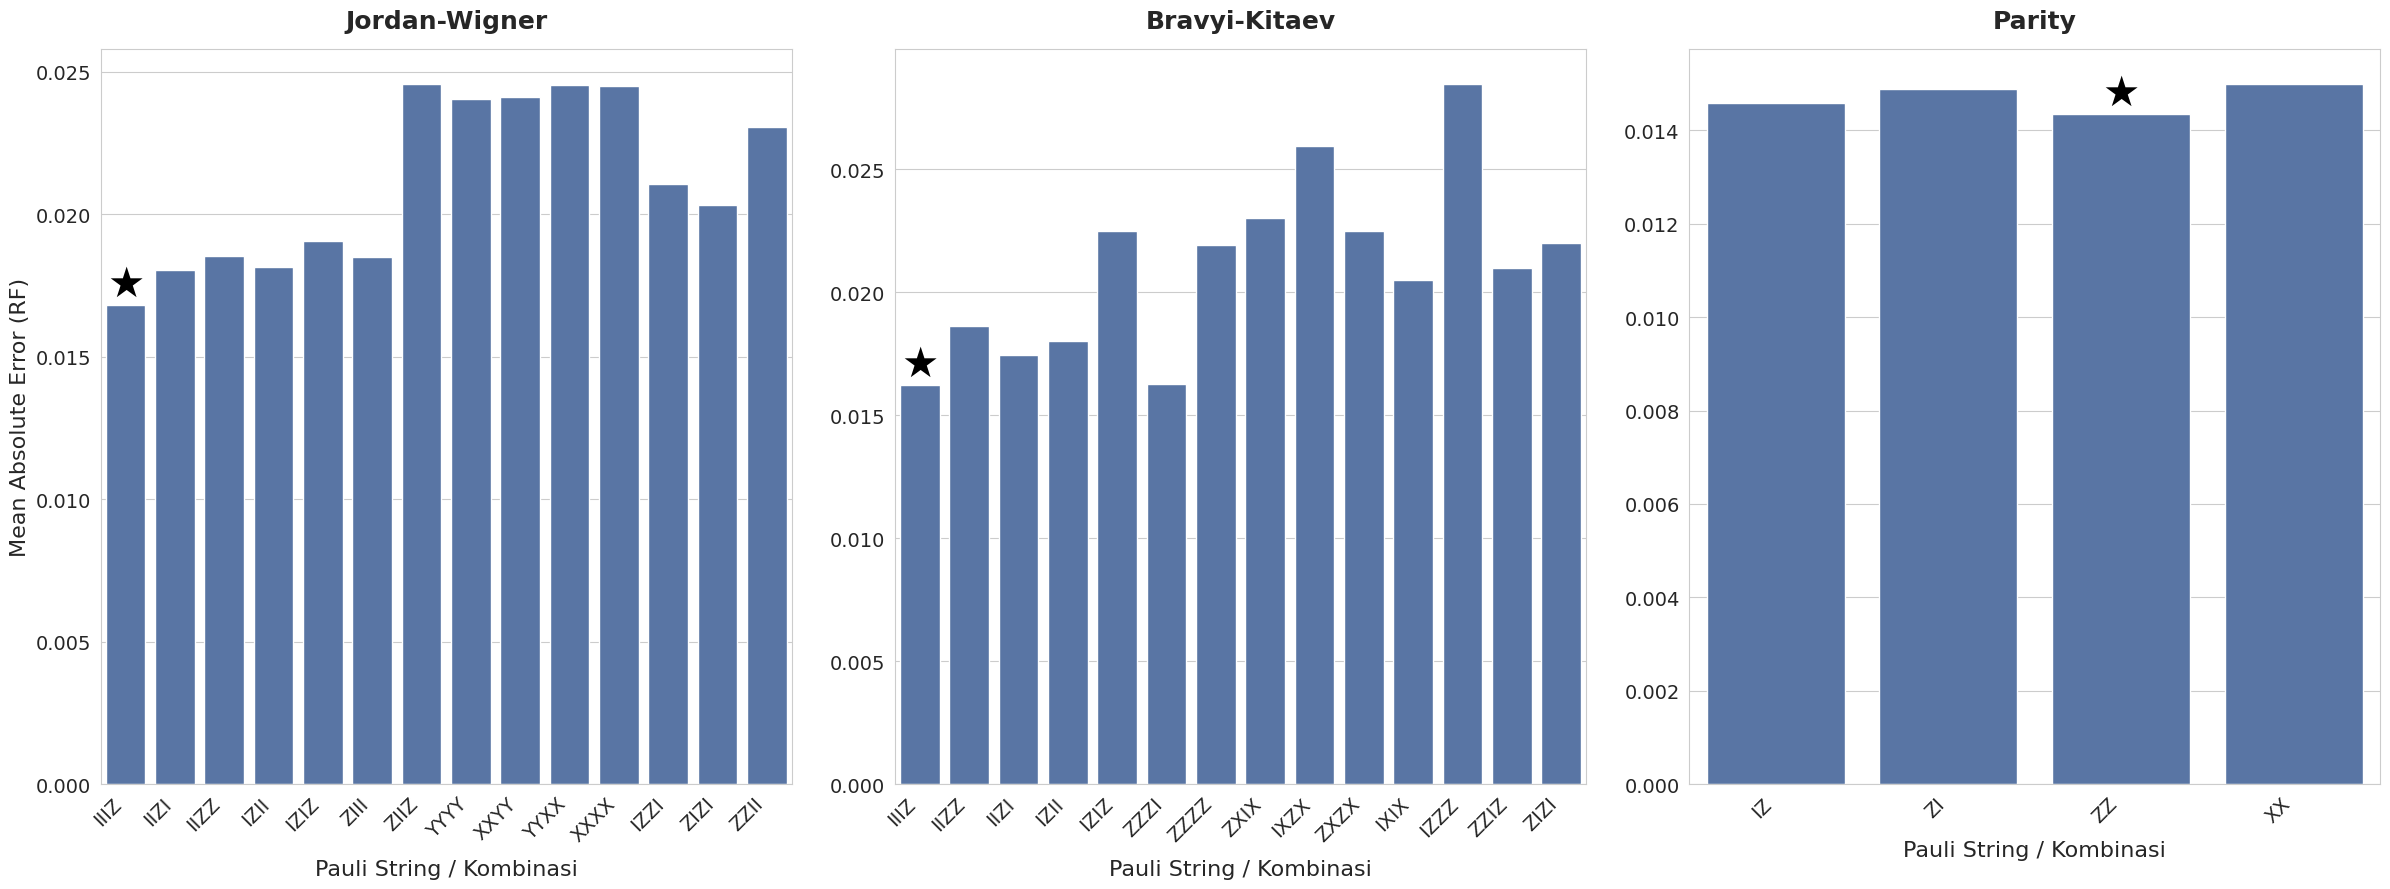

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import numpy as np

# --- 1. CONFIGURATION & MAPPING ---
target_versions = ['V12'] 
target_mappers = ['jw', 'bk', 'parity'] # Sekarang menggunakan list dari mapper
base_root_dir = '../' 
target_cardinality = 'single' # Hanya fokus di satu kardinalitas

# MAPPING DICTIONARY (Jordan-Wigner Pauli Strings)
pauli_map_jw = {
    '1': 'IIII',  '2': 'IIIZ',  '3': 'IIZI',  '4': 'IIZZ',
    '5': 'IZII',  '6': 'IZIZ',  '7': 'ZIII',  '8': 'ZIIZ',
    '9': 'YYYY',  '10': 'XXYY', '11': 'YYXX', '12': 'XXXX',
    '13': 'IZZI', '14': 'ZIZI', '15': 'ZZII'
}

pauli_map_bk = {
    '1': 'IIII',  '2': 'IIIZ',  '3': 'IIZZ',  '4': 'IIZI',
    '5': 'IZII',  '6': 'IZIZ',  '7': 'ZZZI',  '8': 'ZZZZ',
    '9': 'ZXIX',  '10': 'IXZX', '11': 'ZXZX', '12': 'IXIX',
    '13': 'IZZZ', '14': 'ZZIZ', '15': 'ZIZI'
}

pauli_map_parity = {
    '1': 'II',
    '2': 'IZ',
    '3': 'ZI',
    '4': 'ZZ',
    '5': 'XX'
}

# Kamus master untuk memudahkan pemanggilan berdasarkan nama mapper
mapper_dicts = {
    'jw': pauli_map_jw,
    'bk': pauli_map_bk,
    'parity': pauli_map_parity
}

def get_pauli_label(dataset_name, mapper_name):
    match = re.search(r'S-(\d+)', dataset_name)
    if match:
        num_id = match.group(1)
        # Ambil kamus yang sesuai, jika id tidak ada kembalikan dataset_name
        return mapper_dicts.get(mapper_name, {}).get(num_id, dataset_name)
    return dataset_name

def natural_key(text):
    return [int(c) if c.isdigit() else c for c in re.split(r'(\d+)', text)]

# --- 2. LOAD DATA ---
def load_multi_experiments(versions, mappers, root_dir, cardinality):
    all_experiments = []
    
    for ver in versions:
        for mapper in mappers:
            folder_name = f"hasil_eksperimen{ver}_{mapper}"
            full_path = os.path.join(root_dir, folder_name, cardinality)
            
            if not os.path.exists(full_path):
                print(f"Warning: Path tidak ditemukan - {full_path}")
                continue
                
            for dataset_folder in sorted(os.listdir(full_path), key=natural_key):
                csv_path = os.path.join(full_path, dataset_folder, 'ml_training', 'predict_data', 'predicted_data_1.csv')
                
                if os.path.exists(csv_path):
                    df = pd.read_csv(csv_path)
                    mae = (df["RF_energy"] - df["ideal_energy"]).abs().mean()
                    
                    all_experiments.append({
                        'mapper': mapper, # Disimpan untuk pemisahan plotting
                        'dataset_folder': dataset_folder,
                        'pauli_label': get_pauli_label(dataset_folder, mapper),
                        'mae': mae
                    })
    
    return pd.DataFrame(all_experiments)

# Eksekusi fungsi load
df_summary = load_multi_experiments(target_versions, target_mappers, base_root_dir, target_cardinality)

# Filter dataset yang tidak diinginkan
if not df_summary.empty:
    df_summary = df_summary[~df_summary['dataset_folder'].isin(['J-S-1','P-S-1','BK-S-1'])]

# --- 3. VISUALIZATION ---
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(24, 9), sharey=False)
sns.set_style("whitegrid")

# Menentukan warna solid untuk masing-masing mapper
mapper_colors = ['#4C72B0', '#4C72B0', '#4C72B0'] 
mapper_display_names = {'jw': 'Jordan-Wigner', 'bk': 'Bravyi-Kitaev', 'parity': 'Parity'}

for i, mapper in enumerate(target_mappers):
    ax = axes[i]
    if df_summary.empty:
        df_subset = pd.DataFrame()
    else:
        df_subset = df_summary[df_summary['mapper'] == mapper]
    
    if df_subset.empty:
        ax.set_title(f"Data tidak ditemukan\n({mapper_display_names[mapper]})", fontsize=16)
        continue

    # Mengurutkan berdasarkan kunci natural (S-1, S-2, dst)
    unique_datasets_subset = sorted(df_subset['dataset_folder'].unique(), key=natural_key)
    unique_paulis_subset = [get_pauli_label(ds, mapper) for ds in unique_datasets_subset]

    # Plotting bar chart dengan border pada batang
    sns.barplot(
        data=df_subset,
        x='pauli_label',
        y='mae',
        order=unique_paulis_subset, 
        color=mapper_colors[i], 
        ax=ax
    )
    # --- 4. ANNOTATION ---
    for container in ax.containers:
        values = [bar.get_height() for bar in container]
        valid_values = [v for v in values if not np.isnan(v)]
        if not valid_values: continue
        min_val = min(valid_values)
        
        for bar in container:
            height = bar.get_height()
            if np.isnan(height): continue
            if abs(height - min_val) < 1e-9:
                ax.text(
                    bar.get_x() + bar.get_width()/2, height, 
                    '★', ha='center', va='bottom', color='black', fontsize=30, fontweight='bold'
                )

    # --- 5. FORMATTING PER SUBPLOT ---
    ax.set_title(f"{mapper_display_names[mapper]}", fontsize=18, fontweight='bold', pad=15)
    
    if i == 0:
        ax.set_ylabel("Mean Absolute Error (RF)", fontsize=16)
    else:
        ax.set_ylabel("") 
        
    ax.set_xlabel("Pauli String / Kombinasi", fontsize=16, labelpad=10)
    
    ax.tick_params(axis='y', labelsize=14)
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=14)

# Menambahkan judul utama untuk figure
plt.tight_layout()
plt.subplots_adjust(wspace=0.15) 
plt.show()

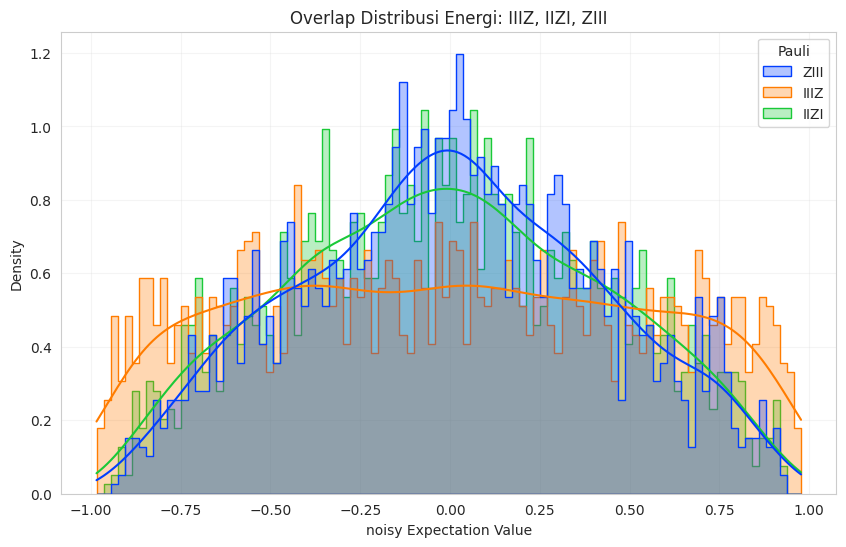

In [45]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

# --- 1. CONFIGURATION ---
target_versions = ['V10'] 
target_mapper = 'jw' 
base_root_dir = '../' 

# Tentukan Pauli String yang ingin di-overlap (Case Sensitive sesuai map)
selected_paulis = ['IIIZ', 'IIZI','ZIII'] 

# Mapping Dictionary
pauli_map_data = {
    '1': 'IIII',  '2': 'IIIZ',  '3': 'IIZI',  '4': 'IIZZ',
    '5': 'IZII',  '6': 'IZIZ',  '7': 'ZIII',  '8': 'ZIIZ',
    '9': 'YYYY',  '10': 'XXYY', '11': 'YYXX', '12': 'XXXX',
    '13': 'IZZI', '14': 'ZIZI', '15': 'ZZII'
}

def get_pauli_info(dataset_name):
    match = re.search(r'S-(\d+)', dataset_name)
    if match:
        num_id = match.group(1)
        return pauli_map_data.get(num_id, dataset_name)
    return dataset_name

# --- 2. LOAD & FILTER DATA ---
def load_selected_data(versions, mapper, root_dir, target_labels):
    all_data = []
    
    for ver in versions:
        base_path = os.path.join(root_dir, f"hasil_eksperimen{ver}_{mapper}", 'single')
        if not os.path.exists(base_path): continue
            
        for folder in os.listdir(base_path):
            if folder.startswith('.'): continue
            
            # Cek apakah folder ini termasuk Pauli yang dipilih
            current_label = get_pauli_info(folder)
            if current_label not in target_labels:
                continue # Skip jika tidak ada di list
                
            csv_path = os.path.join(base_path, folder, 'ml_training', 'train_data', 'train_data_1.csv')
            
            if os.path.exists(csv_path):
                try:
                    df = pd.read_csv(csv_path)
                    if 'noisy_energy' in df.columns:
                        temp = df[['noisy_energy', 'ideal_energy']].copy()
                        temp['Pauli'] = current_label
                        all_data.append(temp)
                except:
                    pass
                    
    if not all_data: return pd.DataFrame()
    return pd.concat(all_data)

# --- 3. PLOTTING OVERLAP ---
df_filtered = load_selected_data(target_versions, target_mapper, base_root_dir, selected_paulis)

if not df_filtered.empty:
    plt.figure(figsize=(10, 6))
    
    # Loop setiap Pauli yang terpilih agar warna konsisten
    # Menggunakan 'histtype="stepfilled"' dengan alpha rendah agar overlap terlihat jelas
    
    # Tips: Gunakan 'density=True' jika jumlah sampel antar Pauli berbeda jauh
    sns.histplot(
        data=df_filtered, 
        x='noisy_energy', 
        hue='Pauli', 
        element="step", # Opsi: 'bars', 'step', 'poly'
        stat="density", # Normalisasi agar area = 1 (penting untuk perbandingan bentuk)
        common_norm=False, 
        kde=True,       # Tambahkan garis density curve
        palette='bright',
        alpha=0.3,      # Transparansi agar yang di belakang terlihat
        bins=100
    )
    
    plt.title(f'Overlap Distribusi Energi: {", ".join(selected_paulis)}')
    plt.xlabel('noisy Expectation Value')
    plt.ylabel('Density')
    plt.grid(True, alpha=0.2)
    plt.show()
else:
    print("Data tidak ditemukan untuk Pauli String yang dipilih.")

Memproses data untuk Pauli: ZIII...

Statistik Ringkas per Eksperimen:
                mean       var       std
Experiment                              
V13        -0.007137  0.190927  0.436952
V14        -0.011150  0.199368  0.446507
V15        -0.012191  0.197251  0.444130


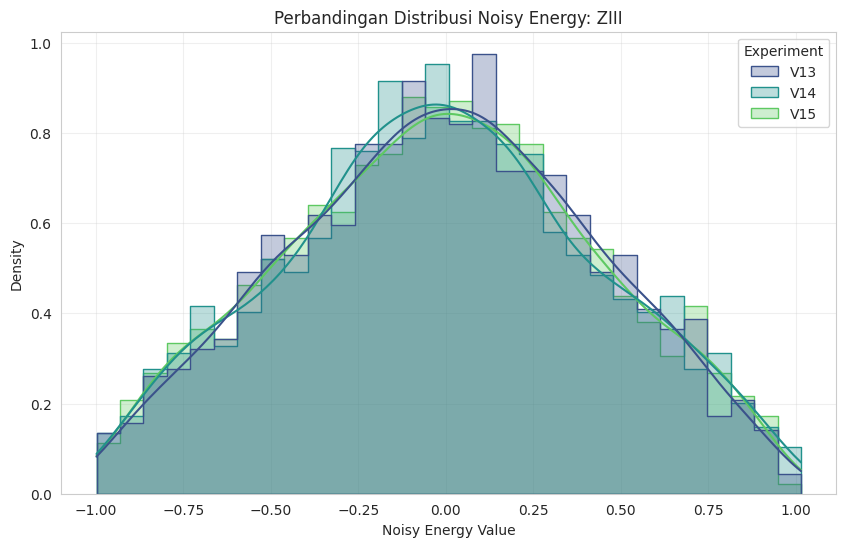

In [52]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

# --- 1. KONFIGURASI ---
# List eksperimen yang ingin dibandingkan
target_versions = ['V13','V14','V15'] 

# Pauli String tunggal yang ingin dianalisis (misal: 'IIII', 'ZIZI', atau 'ZZII')
target_pauli = 'ZIII' 

target_mapper = 'jw' 
base_root_dir = '../' 

# Mapping Dictionary
pauli_map_data = {
    '1': 'IIII',  '2': 'IIIZ',  '3': 'IIZI',  '4': 'IIZZ',
    '5': 'IZII',  '6': 'IZIZ',  '7': 'ZIII',  '8': 'ZIIZ',
    '9': 'YYYY',  '10': 'XXYY', '11': 'YYXX', '12': 'XXXX',
    '13': 'IZZI', '14': 'ZIZI', '15': 'ZZII'
}

# --- 2. HELPER FUNCTIONS ---
def get_pauli_from_folder(folder_name):
    """Mendapatkan Pauli String dari nama folder"""
    match = re.search(r'S-(\d+)', folder_name)
    if match:
        num_id = match.group(1)
        return pauli_map_data.get(num_id, folder_name)
    return None

def load_cross_experiment_data(versions, target_pauli, mapper, root_dir):
    combined_data = []
    
    for ver in versions:
        exp_path = os.path.join(root_dir, f"hasil_eksperimen{ver}_{mapper}", 'single')
        
        if not os.path.exists(exp_path):
            print(f"[WARNING] Folder eksperimen tidak ditemukan: {exp_path}")
            continue
            
        # Cari folder dataset yang sesuai dengan target_pauli
        found_folder = False
        for dataset_folder in os.listdir(exp_path):
            if dataset_folder.startswith('.'): continue
            
            # Cek apakah folder ini adalah Pauli yang kita cari
            if get_pauli_from_folder(dataset_folder) == target_pauli:
                found_folder = True
                csv_path = os.path.join(exp_path, dataset_folder, 'ml_training', 'train_data', 'train_data_1.csv')
                
                if os.path.exists(csv_path):
                    try:
                        df = pd.read_csv(csv_path)
                        if 'noisy_energy' in df.columns:
                            # Ambil data noisy (karena ideal biasanya sama terus)
                            temp = df[['noisy_energy']].copy()
                            temp['Experiment'] = ver  # Label untuk pembeda di plot
                            combined_data.append(temp)
                    except Exception as e:
                        print(f"Error reading {csv_path}: {e}")
                break # Pindah ke versi berikutnya setelah folder ketemu
        
        if not found_folder:
            print(f"[INFO] Pauli {target_pauli} tidak ditemukan di eksperimen {ver}")

    if not combined_data:
        return pd.DataFrame()
    return pd.concat(combined_data, ignore_index=True)

# --- 3. EKSEKUSI & PLOTTING ---
print(f"Memproses data untuk Pauli: {target_pauli}...")
df_cross_exp = load_cross_experiment_data(target_versions, target_pauli, target_mapper, base_root_dir)

if not df_cross_exp.empty:
    plt.figure(figsize=(10, 6))
    
    # Plotting
    sns.histplot(
        data=df_cross_exp, 
        x='noisy_energy', 
        hue='Experiment',     # Warna berbeda tiap eksperimen
        element="step",       # Tampilan garis outline (cleaner untuk overlap)
        stat="density",       # Normalisasi density
        common_norm=False,    # Normalisasi per grup secara independen
        kde=True,             # Tampilkan garis kurva
        palette='viridis',    # Skema warna
        alpha=0.3             # Transparansi
    )
    
    plt.title(f'Perbandingan Distribusi Noisy Energy: {target_pauli}')
    plt.xlabel('Noisy Energy Value')
    plt.ylabel('Density')
    plt.grid(True, alpha=0.3)
    
    # Tampilkan statistik ringkas di console
    print("\nStatistik Ringkas per Eksperimen:")
    stats = df_cross_exp.groupby('Experiment')['noisy_energy'].agg(['mean', 'var', 'std'])
    print(stats)
    
    plt.show()

else:
    print("Tidak ada data yang berhasil dimuat. Periksa nama versi atau path folder.")

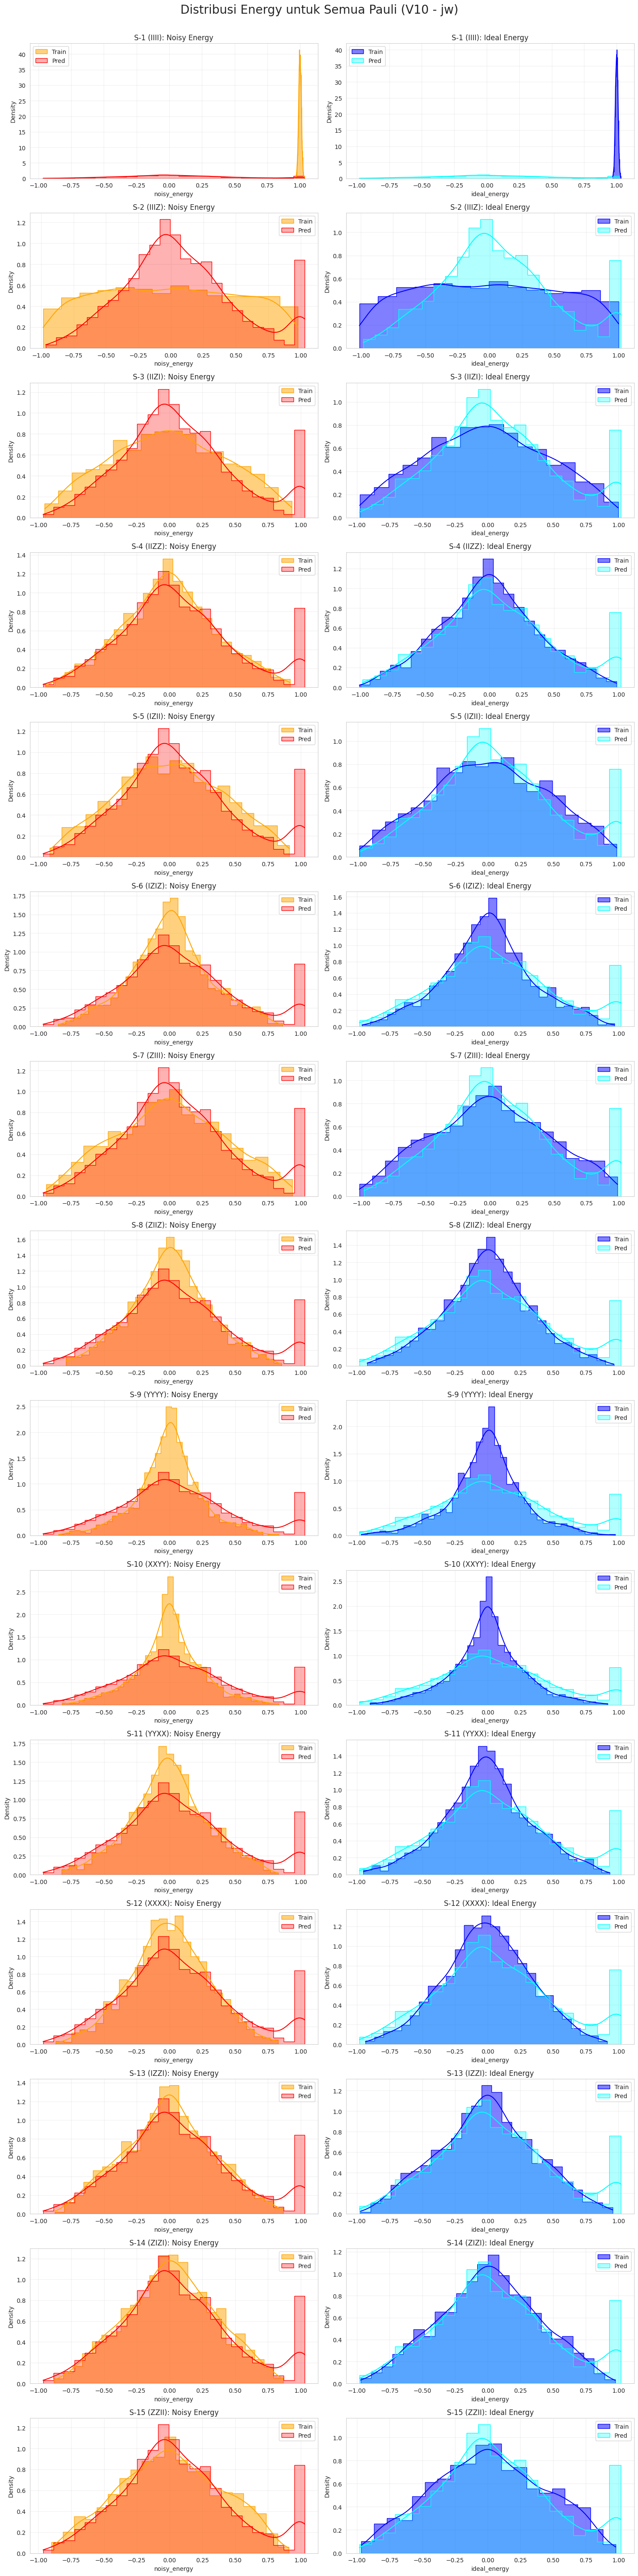

In [9]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

# --- 1. KONFIGURASI ---
target_version = 'V10'
target_mapper = 'jw' 
base_root_dir = '../' 

# Mapping Dictionary - Kita ambil semua kunci dari sini
pauli_map_data = {
    '1': 'IIII',  '2': 'IIIZ',  '3': 'IIZI',  '4': 'IIZZ',
    '5': 'IZII',  '6': 'IZIZ',  '7': 'ZIII',  '8': 'ZIIZ',
    '9': 'YYYY',  '10': 'XXYY', '11': 'YYXX', '12': 'XXXX',
    '13': 'IZZI', '14': 'ZIZI', '15': 'ZZII'
}

# Ambil semua Pauli string berdasarkan urutan kunci (1-15)
target_paulis = [pauli_map_data[str(i)] for i in range(1, 16)]

# --- 2. HELPER FUNCTIONS ---
def get_pauli_info(folder_name):
    match = re.search(r'S-(\d+)', folder_name)
    if match:
        return pauli_map_data.get(match.group(1), folder_name)
    return None

def load_pair_data(version, mapper, root_dir, pauli_str):
    base_path = os.path.join(root_dir, f"hasil_eksperimen{version}_{mapper}", 'single')
    
    if not os.path.exists(base_path):
        return None, None
    
    target_folder = None
    for folder in os.listdir(base_path):
        if get_pauli_info(folder) == pauli_str:
            target_folder = folder
            break
            
    if not target_folder:
        return None, None
        
    full_folder_path = os.path.join(base_path, target_folder)
    train_csv = os.path.join(full_folder_path, 'ml_training', 'train_data', 'train_data_1.csv')
    pred_csv = os.path.join(full_folder_path, 'ml_training', 'predict_data', 'predicted_data_1.csv')
    
    df_train = pd.read_csv(train_csv) if os.path.exists(train_csv) else pd.DataFrame()
    df_pred = pd.read_csv(pred_csv) if os.path.exists(pred_csv) else pd.DataFrame()
        
    return df_train, df_pred

# --- 3. EKSEKUSI & VISUALISASI TOTAL ---

# Setup Figure: 15 Baris (Pauli), 2 Kolom (Noisy & Ideal)
fig, axes = plt.subplots(15, 2, figsize=(15, 60)) # Tinggi disesuaikan agar tidak tumpang tindih
fig.suptitle(f"Distribusi Energy untuk Semua Pauli ({target_version} - {target_mapper})", fontsize=20, y=1.002)

for i, pauli in enumerate(target_paulis):
    df_train, df_pred = load_pair_data(target_version, target_mapper, base_root_dir, pauli)
    
    # Axis untuk Noisy (Kolom 0) dan Ideal (Kolom 1)
    ax_noisy = axes[i, 0]
    ax_ideal = axes[i, 1]

    if df_train.empty and df_pred.empty:
        ax_noisy.text(0.5, 0.5, f"Data {pauli} Tidak Ditemukan", ha='center')
        ax_ideal.text(0.5, 0.5, f"Data {pauli} Tidak Ditemukan", ha='center')
        continue

    # --- PLOT KOLOM 1: NOISY ENERGY ---
    if not df_train.empty:
        sns.histplot(df_train['noisy_energy'], ax=ax_noisy, color='orange', alpha=0.5, 
                     label='Train', stat='density', kde=True, element='step')
    if not df_pred.empty:
        sns.histplot(df_pred['noisy_energy'], ax=ax_noisy, color='red', alpha=0.3, 
                     label='Pred', stat='density', kde=True, element='step')
    
    ax_noisy.set_title(f"S-{i+1} ({pauli}): Noisy Energy")
    ax_noisy.legend()
    ax_noisy.grid(True, alpha=0.3)

    # --- PLOT KOLOM 2: IDEAL ENERGY ---
    if not df_train.empty:
        sns.histplot(df_train['ideal_energy'], ax=ax_ideal, color='blue', alpha=0.5, 
                     label='Train', stat='density', kde=True, element='step')
    if not df_pred.empty:
        sns.histplot(df_pred['ideal_energy'], ax=ax_ideal, color='cyan', alpha=0.3, 
                     label='Pred', stat='density', kde=True, element='step')
    
    ax_ideal.set_title(f"S-{i+1} ({pauli}): Ideal Energy")
    ax_ideal.legend()
    ax_ideal.grid(True, alpha=0.3)

# Layout Adjustment
plt.tight_layout()
plt.show()

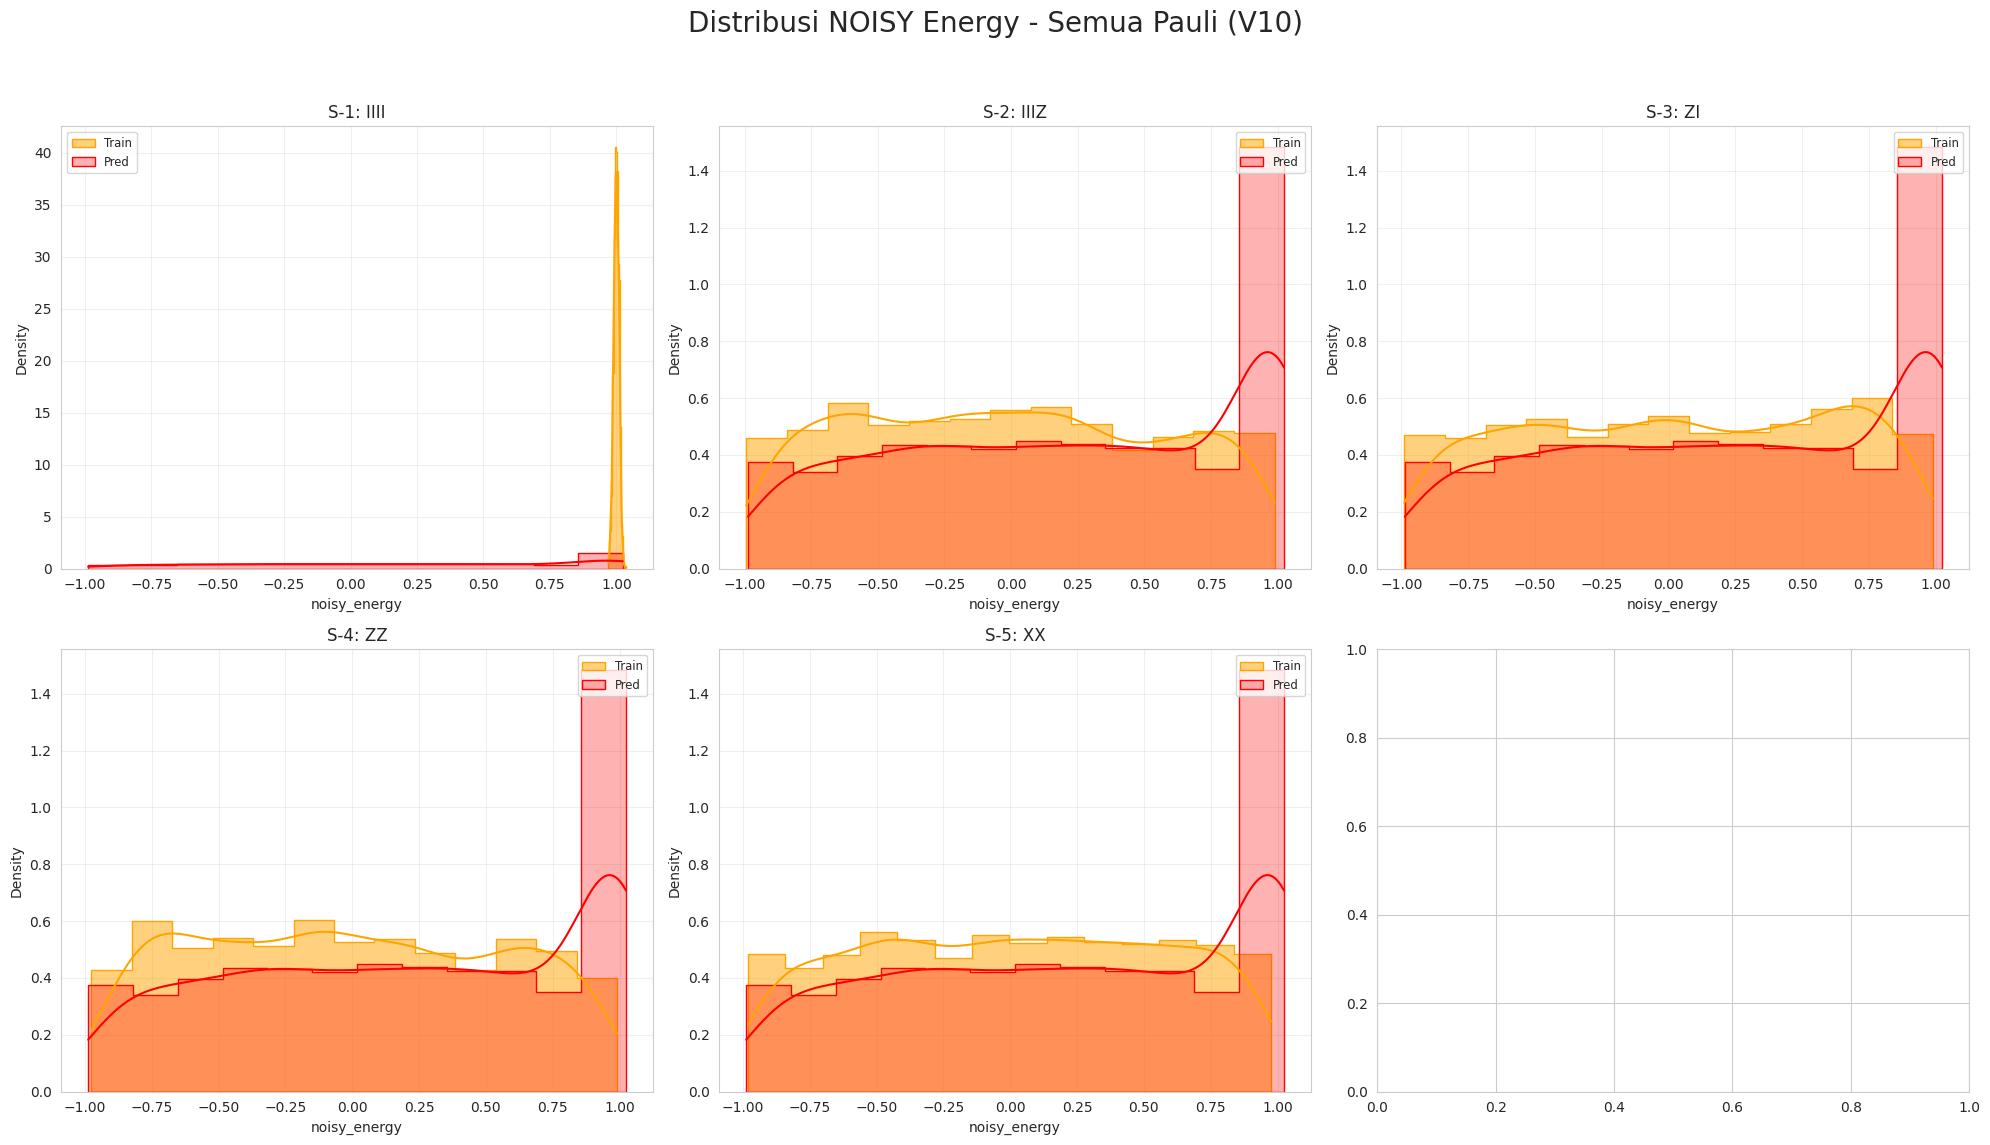

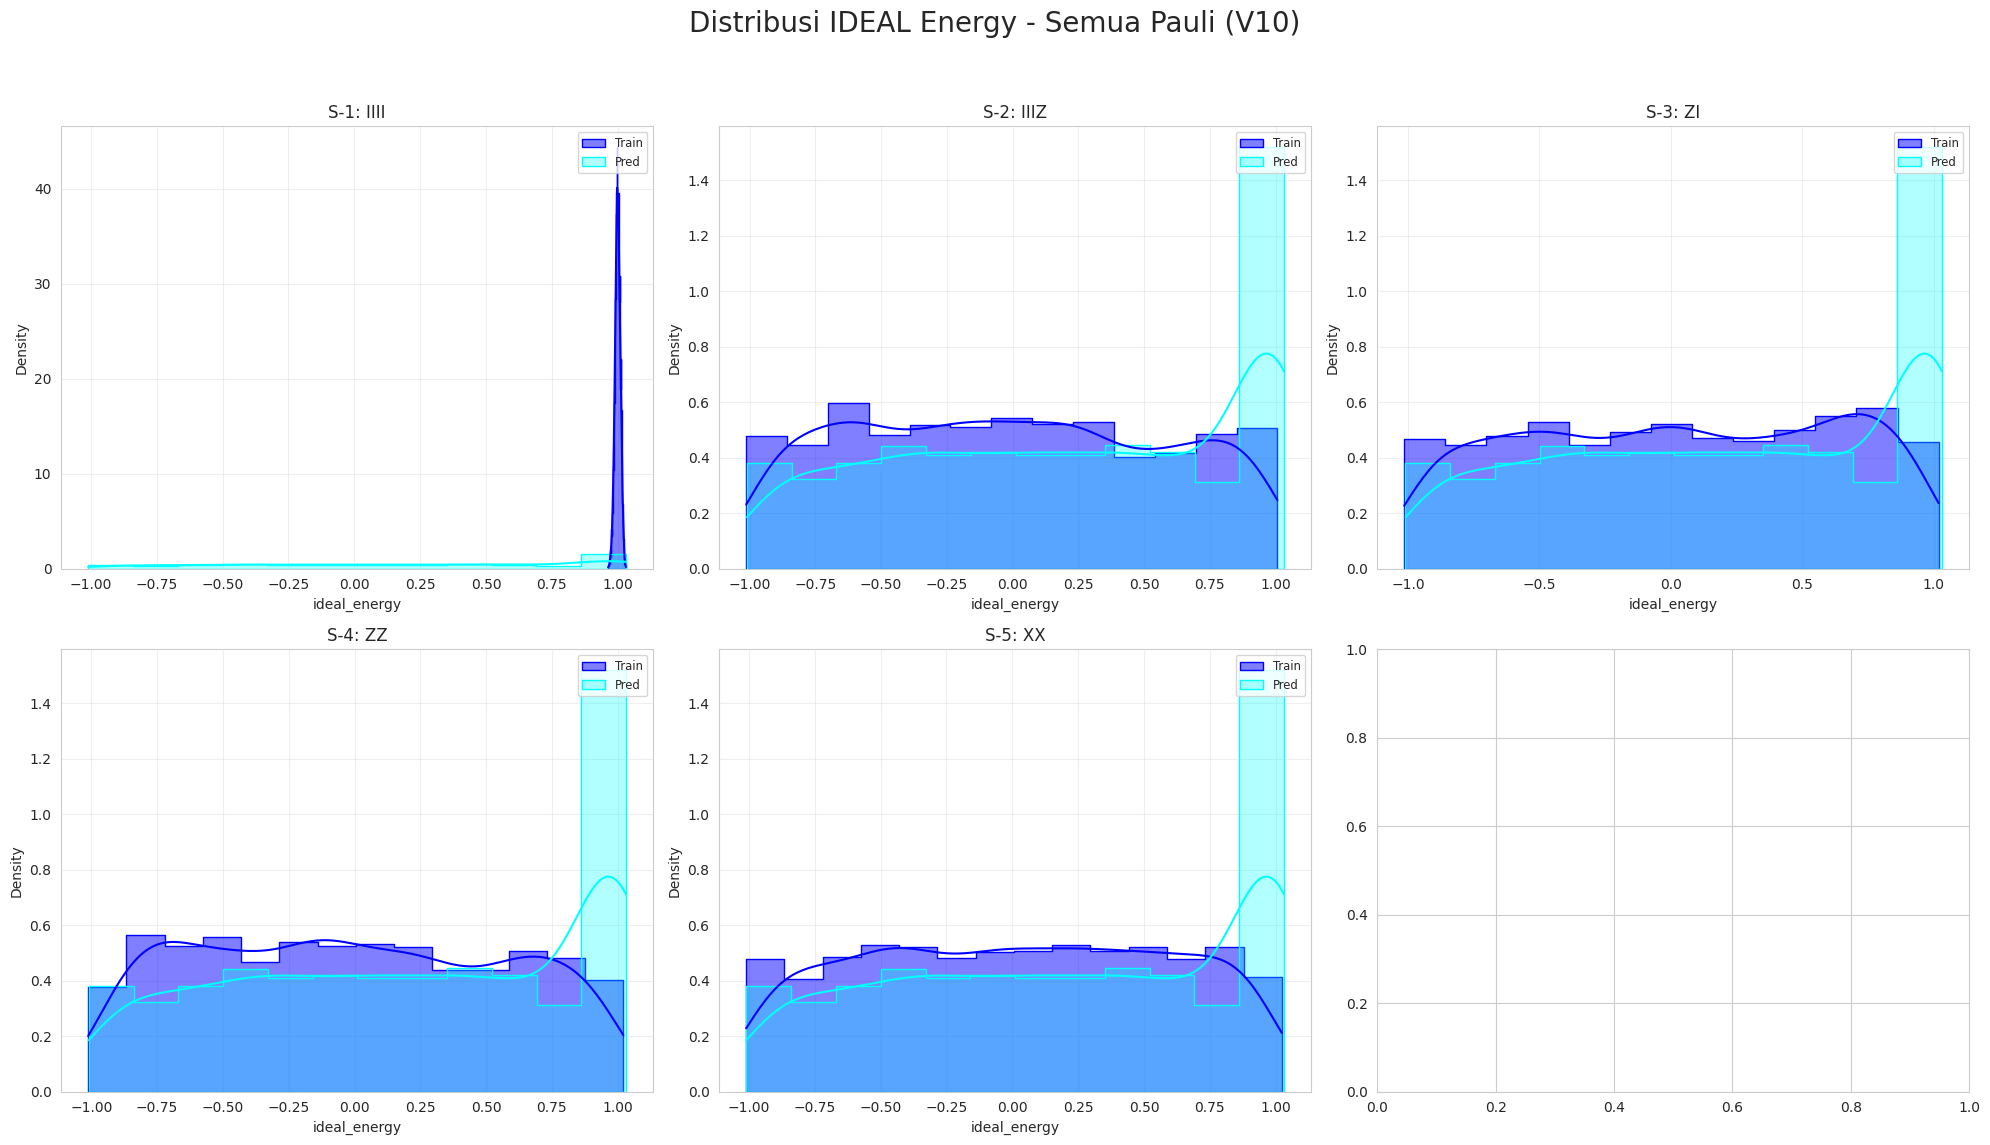

In [17]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

# --- 1. KONFIGURASI ---
target_version = 'V10'
target_mapper = 'parity' 
base_root_dir = '../' 

# Mapping Dictionary
# pauli_map_data = {
#     '1': 'IIII',  '2': 'IIIZ',  '3': 'IIZI',  '4': 'IIZZ',
#     '5': 'IZII',  '6': 'IZIZ',  '7': 'ZIII',  '8': 'ZIIZ',
#     '9': 'YYYY',  '10': 'XXYY', '11': 'YYXX', '12': 'XXXX',
#     '13': 'IZZI', '14': 'ZIZI', '15': 'ZZII'
# }

pauli_map_data = {
    '1':'IIII','2': 'IIIZ',  '3': 'ZI',  '4': 'ZZ',
    '5': 'XX' }

# Ambil semua Pauli string (1-15)
target_paulis = [pauli_map_data[str(i)] for i in range(1, 6)]

# --- 2. HELPER FUNCTIONS ---
def get_pauli_info(folder_name):
    match = re.search(r'S-(\d+)', folder_name)
    if match:
        return pauli_map_data.get(match.group(1), folder_name)
    return None

def load_pair_data(version, mapper, root_dir, pauli_str):
    base_path = os.path.join(root_dir, f"hasil_eksperimen{version}_{mapper}", 'single')
    
    if not os.path.exists(base_path):
        return None, None
    
    target_folder = None
    for folder in os.listdir(base_path):
        if get_pauli_info(folder) == pauli_str:
            target_folder = folder
            break
            
    if not target_folder:
        return None, None
        
    full_folder_path = os.path.join(base_path, target_folder)
    train_csv = os.path.join(full_folder_path, 'ml_training', 'train_data', 'train_data_1.csv')
    pred_csv = os.path.join(full_folder_path, 'ml_training', 'predict_data', 'predicted_data_1.csv')
    
    df_train = pd.read_csv(train_csv) if os.path.exists(train_csv) else pd.DataFrame()
    df_pred = pd.read_csv(pred_csv) if os.path.exists(pred_csv) else pd.DataFrame()
        
    return df_train, df_pred

# --- 3. EKSEKUSI VISUALISASI ---

# --- FIGURE 1: NOISY ENERGY (3x5) ---
fig1, axes1 = plt.subplots(2, 3, figsize=(20, 12))
fig1.suptitle(f"Distribusi NOISY Energy - Semua Pauli ({target_version})", fontsize=20)

for i, pauli in enumerate(target_paulis):
    row, col = divmod(i, 3)
    ax = axes1[row, col]
    
    df_train, df_pred = load_pair_data(target_version, target_mapper, base_root_dir, pauli)
    
    if not df_train.empty:
        sns.histplot(df_train['noisy_energy'], ax=ax, color='orange', alpha=0.5, 
                     label='Train', stat='density', kde=True, element='step')
    if not df_pred.empty:
        sns.histplot(df_pred['noisy_energy'], ax=ax, color='red', alpha=0.3, 
                     label='Pred', stat='density', kde=True, element='step')
    
    ax.set_title(f"S-{i+1}: {pauli}")
    ax.legend(fontsize='small')
    ax.grid(True, alpha=0.3)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('distribution_noisy_3x5.png')
plt.show()


# --- FIGURE 2: IDEAL ENERGY (3x5) ---
fig2, axes2 = plt.subplots(2, 3, figsize=(20, 12))
fig2.suptitle(f"Distribusi IDEAL Energy - Semua Pauli ({target_version})", fontsize=20)

for i, pauli in enumerate(target_paulis):
    row, col = divmod(i, 3)
    ax = axes2[row, col]
    
    df_train, df_pred = load_pair_data(target_version, target_mapper, base_root_dir, pauli)
    
    if not df_train.empty:
        sns.histplot(df_train['ideal_energy'], ax=ax, color='blue', alpha=0.5, 
                     label='Train', stat='density', kde=True, element='step')
    if not df_pred.empty:
        sns.histplot(df_pred['ideal_energy'], ax=ax, color='cyan', alpha=0.3, 
                     label='Pred', stat='density', kde=True, element='step')
    
    ax.set_title(f"S-{i+1}: {pauli}")
    ax.legend(fontsize='small')
    ax.grid(True, alpha=0.3)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('distribution_ideal_3x5.png')
plt.show()

Pauli Label  Signal Var  Noise Var  SNR (dB)
       IIII    0.000099   0.000208 -3.251096
       IIIZ    0.307702   0.000548 27.495346
       IIZI    0.212180   0.000918 23.640049
       IIZZ    0.142519   0.000766 22.696897
       IZII    0.193253   0.001696 20.568130
       IZIZ    0.114624   0.001486 18.871799
       ZIII    0.205083   0.001618 21.028523
       ZIIZ    0.110478   0.001451 18.816076
       YYYY    0.076923   0.001278 17.794115
       XXYY    0.079509   0.001014 18.945505
       YYXX    0.110920   0.001798 17.902958
       XXXX    0.108417   0.001498 18.596421
       IZZI    0.139003   0.001458 19.793198
       ZIZI    0.145673   0.001654 19.449065
       ZZII    0.182953   0.001800 20.070949


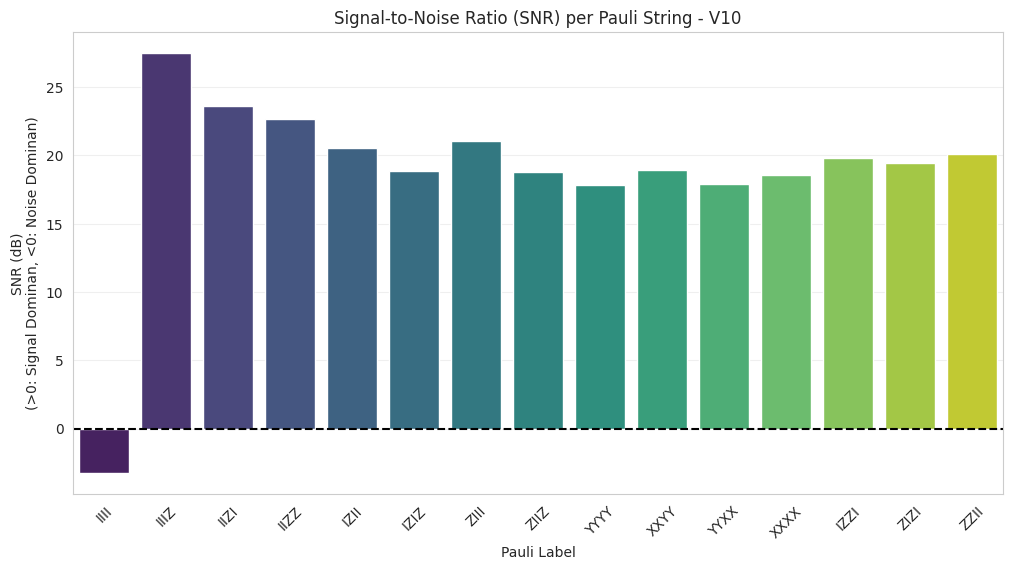

In [55]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

# --- KONFIGURASI ---
target_version = 'V10'
target_mapper = 'jw'
base_root_dir = '../'

# Mapping Dictionary
pauli_map_data = {
    '1': 'IIII',  '2': 'IIIZ',  '3': 'IIZI',  '4': 'IIZZ',
    '5': 'IZII',  '6': 'IZIZ',  '7': 'ZIII',  '8': 'ZIIZ',
    '9': 'YYYY',  '10': 'XXYY', '11': 'YYXX', '12': 'XXXX',
    '13': 'IZZI', '14': 'ZIZI', '15': 'ZZII'
}

def get_pauli_info(dataset_name):
    match = re.search(r'S-(\d+)', dataset_name)
    if match:
        pid = int(match.group(1))
        return pid, pauli_map_data.get(str(pid), dataset_name)
    return 999, dataset_name

# --- LOAD DATA ---
def calculate_snr_per_pauli(version, mapper, root_dir):
    full_path = os.path.join(root_dir, f"hasil_eksperimen{version}_{mapper}", 'single')
    if not os.path.exists(full_path):
        print("Path tidak ditemukan.")
        return pd.DataFrame()

    results = []
    
    for folder in os.listdir(full_path):
        if folder.startswith('.'): continue
        
        csv_path = os.path.join(full_path, folder, 'ml_training', 'train_data', 'train_data_1.csv')
        
        if os.path.exists(csv_path):
            try:
                df = pd.read_csv(csv_path)
                if 'noisy_energy' in df.columns and 'ideal_energy' in df.columns:
                    
                    # 1. Hitung Signal Power (Variansi Ideal)
                    signal_var = df['ideal_energy'].var()
                    
                    # 2. Hitung Noise Power (Variansi dari Error/Residual)
                    # Kita pakai selisihnya, karena noise adalah deviasi dari ideal
                    noise_residuals = df['noisy_energy'] - df['ideal_energy']
                    noise_var = noise_residuals.var()
                    
                    # 3. Hitung SNR
                    # Tambahkan epsilon kecil agar tidak bagi dengan nol
                    if noise_var == 0: noise_var = 1e-10
                    snr_linear = signal_var / noise_var
                    snr_db = 10 * np.log10(snr_linear) if snr_linear > 0 else -np.inf
                    
                    pid, label = get_pauli_info(folder)
                    
                    results.append({
                        'Pauli ID': pid,
                        'Pauli Label': label,
                        'Signal Var': signal_var,
                        'Noise Var': noise_var,
                        'SNR (linear)': snr_linear,
                        'SNR (dB)': snr_db
                    })
            except:
                pass

    return pd.DataFrame(results).sort_values('Pauli ID')

# --- EKSEKUSI ---
df_snr = calculate_snr_per_pauli(target_version, target_mapper, base_root_dir)

if not df_snr.empty:
    print(df_snr[['Pauli Label', 'Signal Var', 'Noise Var', 'SNR (dB)']].to_string(index=False))

    # Visualisasi Bar Chart SNR
    plt.figure(figsize=(12, 6))
    
    # Warna: Hijau jika SNR positif (Bagus), Merah jika negatif (Buruk)
    colors = ['green' if x >= 0 else 'red' for x in df_snr['SNR (dB)']]
    
    sns.barplot(data=df_snr, x='Pauli Label', y='SNR (dB)', hue='Pauli Label', palette='viridis')
    plt.axhline(0, color='black', linestyle='--')
    plt.title(f'Signal-to-Noise Ratio (SNR) per Pauli String - {target_version}')
    plt.ylabel('SNR (dB)\n(>0: Signal Dominan, <0: Noise Dominan)')
    plt.grid(axis='y', alpha=0.3)
    plt.xticks(rotation=45)
    plt.show()
else:
    print("Data kosong.")

Mengumpulkan dan menghitung metrik...
 -> IIIZ: OK
 -> IIZI: OK
 -> IIZZ: OK
 -> IZII: OK
 -> IZIZ: OK
 -> ZIII: OK
 -> ZIIZ: OK
 -> YYYY: OK
 -> XXYY: OK
 -> YYXX: OK
 -> XXXX: OK
 -> IZZI: OK
 -> ZIZI: OK
 -> ZZII: OK


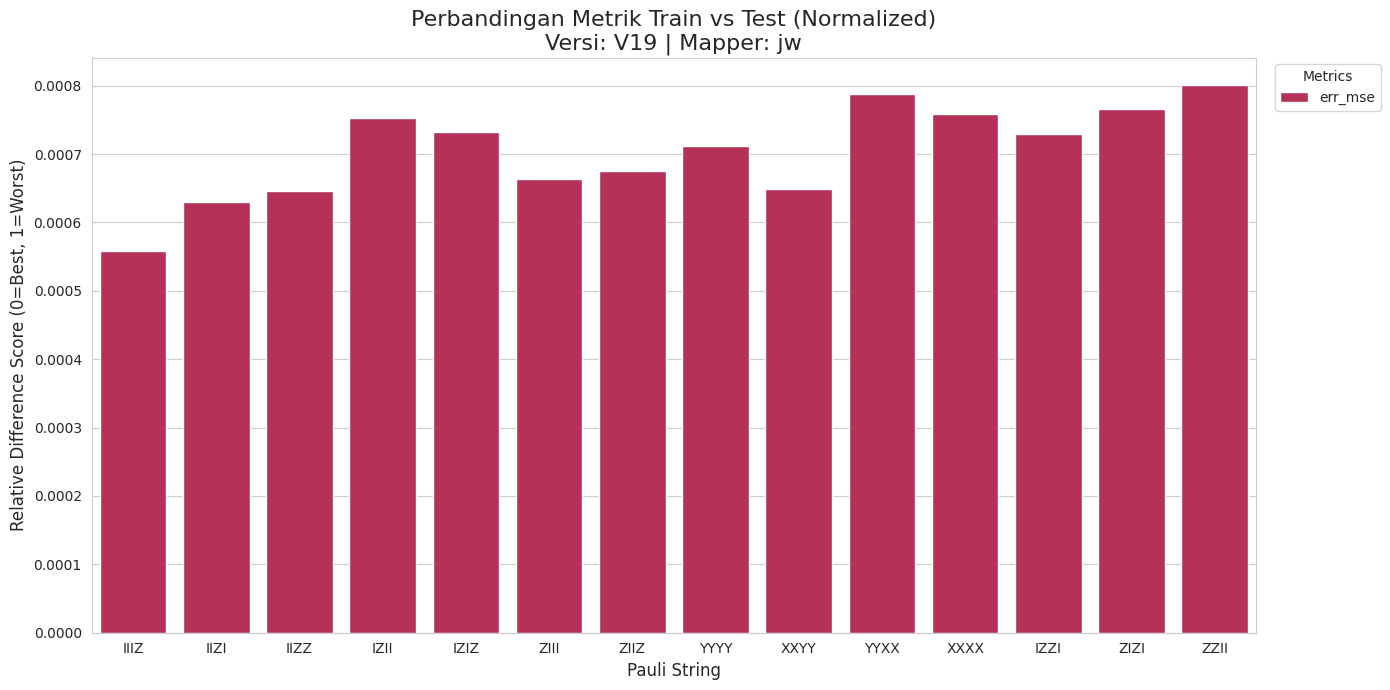


--- Data Metrik Asli (Sebelum Normalisasi) ---
       err_mse
Pauli         
IIIZ    0.0006
IIZI    0.0006
IIZZ    0.0006
IZII    0.0008
IZIZ    0.0007
ZIII    0.0007
ZIIZ    0.0007
YYYY    0.0007
XXYY    0.0006
YYXX    0.0008
XXXX    0.0008
IZZI    0.0007
ZIZI    0.0008
ZZII    0.0008


In [185]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import numpy as np
from scipy.stats import wasserstein_distance, pearsonr, entropy, spearmanr
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import mutual_info_regression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import StratifiedKFold, cross_val_predict

# --- 1. KONFIGURASI ---
target_version = 'V19'   
target_mapper = 'jw' 
base_root_dir = '../' 

# Target Pauli yang akan dibandingkan
target_paulis = ['IIIZ', 'IIZI', 'IIZZ', 'IZII', 'IZIZ', 'ZIII', 'ZIIZ', 
                 'YYYY', 'XXYY', 'YYXX', 'XXXX', 'IZZI', 'ZIZI', 'ZZII']

# Mapping Dictionary
pauli_map_data = {
    '1': 'IIII',  '2': 'IIIZ',  '3': 'IIZI',  '4': 'IIZZ',
    '5': 'IZII',  '6': 'IZIZ',  '7': 'ZIII',  '8': 'ZIIZ',
    '9': 'YYYY',  '10': 'XXYY', '11': 'YYXX', '12': 'XXXX',
    '13': 'IZZI', '14': 'ZIZI', '15': 'ZZII'
}

# --- 2. HELPER FUNCTIONS ---
def get_pauli_info(folder_name):
    match = re.search(r'S-(\d+)', folder_name)
    if match:
        return pauli_map_data.get(match.group(1), folder_name)
    return None

def load_pair_data(version, mapper, root_dir, pauli_str):
    base_path = os.path.join(root_dir, f"hasil_eksperimen{version}_{mapper}", 'single')
    if not os.path.exists(base_path): return None, None
    
    # Cari folder yang sesuai
    target_folder = next((f for f in os.listdir(base_path) if get_pauli_info(f) == pauli_str), None)
    if not target_folder: return None, None
        
    full_folder_path = os.path.join(base_path, target_folder)
    train_csv = os.path.join(full_folder_path, 'ml_training', 'train_data', 'train_data_1.csv')
    pred_csv = os.path.join(full_folder_path, 'ml_training', 'predict_data', 'predicted_data_1.csv')
    
    df_train = pd.read_csv(train_csv) if os.path.exists(train_csv) else None
    df_pred = pd.read_csv(pred_csv) if os.path.exists(pred_csv) else None
    return df_train, df_pred

def calculate_metrics(df_train, df_test):
    metrics = {}
    
    # metrics['corr'] = spearmanr(df_train['noisy_energy'], df_test['noisy_energy']).statistic
    err_train = abs(df_train['ideal_energy'] - df_train['noisy_energy'])
    err_test = abs(df_test['ideal_energy'] - df_test['noisy_energy'])
    metrics['err_mse'] = mean_squared_error(err_train,err_test) 
    # metrics['mse'] = mean_absolute_error(df_train['ideal_energy'], df_test['ideal_energy'])

    return metrics

# --- 3. EKSEKUSI & PENGUMPULAN DATA ---
all_results = []

print("Mengumpulkan dan menghitung metrik...")
for pauli in target_paulis:
    df_train, df_test = load_pair_data(target_version, target_mapper, base_root_dir, pauli)
    
    if df_train is not None and df_test is not None:
        try:
            res = calculate_metrics(df_train, df_test)
            res['Pauli'] = pauli
            all_results.append(res)
            print(f" -> {pauli}: OK")
        except Exception as e:
            print(f" -> {pauli}: Gagal ({e})")
    else:
        print(f" -> {pauli}: Data tidak ditemukan")

# Buat DataFrame
df_metrics = pd.DataFrame(all_results)

# --- 4. NORMALISASI & VISUALISASI ---
if not df_metrics.empty:
    
    
    # Melt data untuk Seaborn
    df_melted = df_metrics.melt(id_vars='Pauli', var_name='Metric', value_name='Normalized Score')

    # Plot
    plt.figure(figsize=(14, 7))
    sns.set_style("whitegrid")
    
    # Bar Plot
    ax = sns.barplot(data=df_melted, x='Pauli', y='Normalized Score', hue='Metric', palette='rocket')
    
    plt.title(f'Perbandingan Metrik Train vs Test (Normalized)\nVersi: {target_version} | Mapper: {target_mapper}', fontsize=16)
    plt.ylabel('Relative Difference Score (0=Best, 1=Worst)', fontsize=12)
    plt.xlabel('Pauli String', fontsize=12)
    plt.legend(title='Metrics', bbox_to_anchor=(1.01, 1), loc='upper left')
    
    plt.tight_layout()
    plt.show()
    
    # Tampilkan tabel data asli untuk referensi angka absolut
    print("\n--- Data Metrik Asli (Sebelum Normalisasi) ---")
    print(df_metrics.set_index('Pauli').round(4))

else:
    print("Tidak ada data yang berhasil diproses.")